In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuration et chemins des rapports v3
sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BACKTEST_PATH = ROOT / "outputs" / "reports" / "backtest_v3_results.csv"
WARNING_PATH = ROOT / "outputs" / "reports" / "warning_metrics_v3.csv"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not BACKTEST_PATH.exists():
    raise FileNotFoundError(f"Backtest report introuvable : {BACKTEST_PATH}")
if not WARNING_PATH.exists():
    raise FileNotFoundError(f"Warning report introuvable : {WARNING_PATH}")

# Chargement des sorties d'évaluation
backtest = pd.read_csv(BACKTEST_PATH)
warning = pd.read_csv(WARNING_PATH)
display(backtest.head())
display(warning.head())


,bloc,model,rmse,mae,mape,n_test
0,A,naif,1.376287,1.033333,1.014112,24
1,A,sarima,1.913106,1.546841,1.515827,24
2,A,sarimax_behavioral,1.806660,1.476210,1.449216,24
3,A,sarimax_hybrid,2.003609,1.600461,1.571055,24
4,B,naif,1.842553,1.366667,1.112965,36


,scope,signal,signal_col,threshold_from,threshold_calibrated,auc,f1,precision,recall,lead_time_mean_months,tp,fp,fn,n_positive,n_total
0,test_A,behavioral,behavioral_index_pure_lag1,train_A,0.4629,0.3281,0.2727,0.2143,0.375,1.0,3,11,5,8,24
1,test_A,hybrid,hybrid_macro_index_lag1,train_A,0.2348,0.5625,0.5000,0.3333,1.000,1.0,8,16,0,8,24
2,test_B,behavioral,behavioral_index_pure_lag1,train_B,0.2401,0.3106,0.8136,0.6857,1.000,NaN,24,11,0,24,35
3,test_B,hybrid,hybrid_macro_index_lag1,train_B,0.2348,0.3561,0.4390,0.5294,0.375,NaN,9,8,15,24,35
4,global,behavioral,behavioral_index_pure_lag1,median_of_trains,0.3515,0.6233,0.6316,0.4865,0.900,1.0,36,38,4,40,84


In [2]:
# Tableau RMSE / MAE / MAPE par bloc et par modèle
required_backtest_cols = {"bloc", "model", "rmse", "mae", "mape"}
missing_backtest = required_backtest_cols - set(backtest.columns)
if missing_backtest:
    raise KeyError(f"Colonnes manquantes dans backtest_v3_results.csv : {sorted(missing_backtest)}")

metrics_table = (
    backtest
    .pivot_table(index=["bloc", "model"], values=["rmse", "mae", "mape"], aggfunc="mean")
    .sort_index()
)
display(metrics_table)


mae      mape      rmse
bloc model                                           
A    naif                1.033333  1.014112  1.376287
     sarima              1.546841  1.515827  1.913106
     sarimax_behavioral  1.476210  1.449216  1.806660
     sarimax_hybrid      1.600461  1.571055  2.003609
B    naif                1.366667  1.112965  1.842553
     sarima              1.527700  1.243277  1.932367
     sarimax_behavioral  1.568771  1.276664  1.976062
     sarimax_hybrid      1.552498  1.263282  1.991125

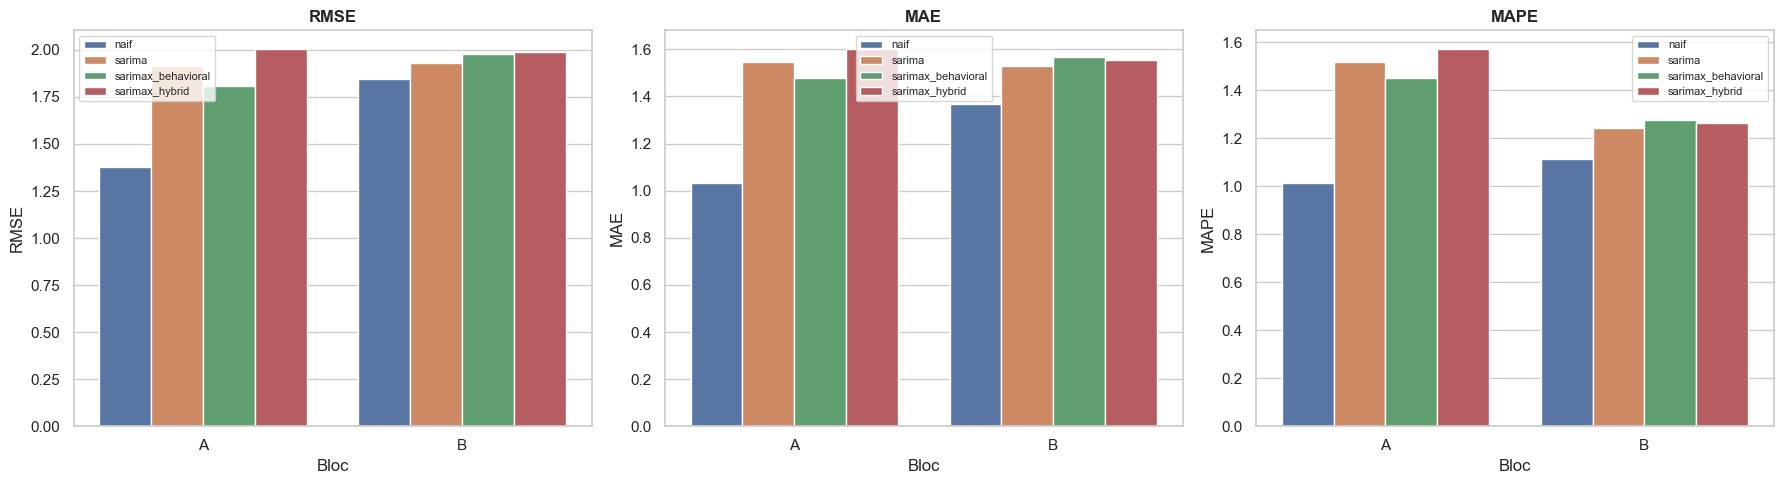

In [3]:
# Visualisation des métriques du backtest par bloc
plot_df = backtest.copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
for ax, metric in zip(axes, ["rmse", "mae", "mape"]):
    sns.barplot(data=plot_df, x="bloc", y=metric, hue="model", ax=ax)
    ax.set_title(metric.upper(), fontweight="bold")
    ax.set_xlabel("Bloc")
    ax.set_ylabel(metric.upper())
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "nb04_backtest_metrics_v3.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)


In [4]:
# Tableau des métriques d'alerte (AUC, F1, lead-time) pour les signaux behavioral / hybrid
required_warning_cols = {"scope", "signal", "auc", "f1", "precision", "recall", "lead_time_mean_months"}
missing_warning = required_warning_cols - set(warning.columns)
if missing_warning:
    raise KeyError(f"Colonnes manquantes dans warning_metrics_v3.csv : {sorted(missing_warning)}")

warning_global = warning[warning["scope"] == "global"].copy()
warning_global = warning_global.sort_values("signal")
display(warning_global[["signal", "auc", "f1", "precision", "recall", "lead_time_mean_months", "tp", "fp", "fn"]])


,signal,auc,f1,precision,recall,lead_time_mean_months,tp,fp,fn
4,behavioral,0.6233,0.6316,0.4865,0.900,1.0,36,38,4
5,hybrid,0.4511,0.5376,0.4717,0.625,1.0,25,28,15


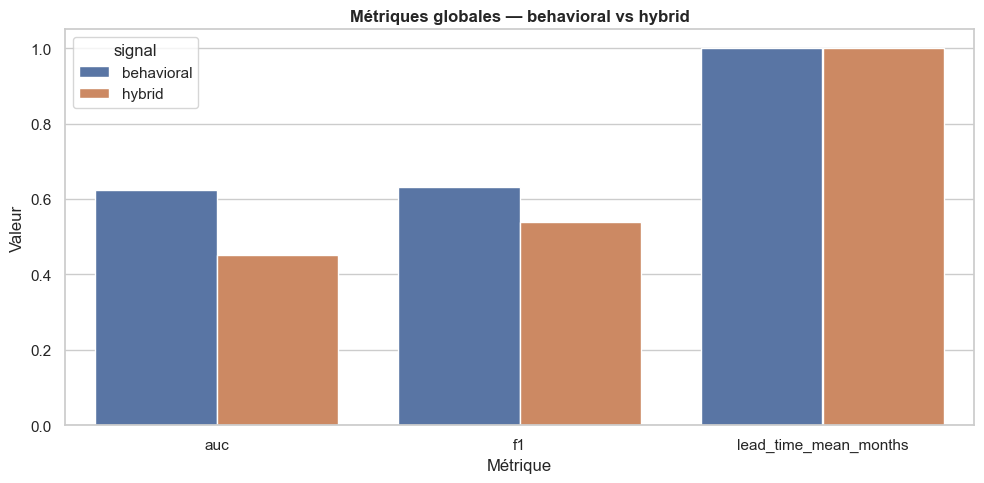

In [5]:
# Visualisation comparée AUC / F1 / lead-time
metrics_long = warning_global[["signal", "auc", "f1", "lead_time_mean_months"]].melt(
    id_vars="signal", var_name="metric", value_name="value"
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metrics_long, x="metric", y="value", hue="signal", ax=ax)
ax.set_title("Métriques globales — behavioral vs hybrid", fontweight="bold")
ax.set_xlabel("Métrique")
ax.set_ylabel("Valeur")
fig.tight_layout()
fig.savefig(FIG_DIR / "nb04_warning_summary_v3.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)


In [6]:
# Conclusion H1 / H2 avec les chiffres réels
behavioral_row = warning_global[warning_global["signal"] == "behavioral"]
hybrid_row = warning_global[warning_global["signal"] == "hybrid"]

if behavioral_row.empty:
    raise ValueError("Signal behavioral absent des métriques globales")

auc_behavioral = float(behavioral_row["auc"].iloc[0])
f1_behavioral = float(behavioral_row["f1"].iloc[0])
lead_behavioral = float(behavioral_row["lead_time_mean_months"].iloc[0]) if not pd.isna(behavioral_row["lead_time_mean_months"].iloc[0]) else np.nan

h1_status = "VALIDÉE" if auc_behavioral > 0.65 else "REJETÉE"

if hybrid_row.empty:
    auc_hybrid = np.nan
    f1_hybrid = np.nan
    lead_hybrid = np.nan
    delta_auc = np.nan
    h2_status = "NON TESTABLE"
else:
    auc_hybrid = float(hybrid_row["auc"].iloc[0])
    f1_hybrid = float(hybrid_row["f1"].iloc[0])
    lead_hybrid = float(hybrid_row["lead_time_mean_months"].iloc[0]) if not pd.isna(hybrid_row["lead_time_mean_months"].iloc[0]) else np.nan
    delta_auc = auc_hybrid - auc_behavioral
    h2_status = "VALIDÉE" if delta_auc > 0.05 else "REJETÉE"

conclusion_df = pd.DataFrame([
    {
        "hypothese": "H1",
        "regle": "AUC behavioral > 0.65",
        "valeur": round(auc_behavioral, 4),
        "statut": h1_status,
    },
    {
        "hypothese": "H2",
        "regle": "AUC hybrid - AUC behavioral > 0.05",
        "valeur": round(delta_auc, 4) if not pd.isna(delta_auc) else np.nan,
        "statut": h2_status,
    },
])
display(conclusion_df)

print(f"H1 : {h1_status} | behavioral AUC={auc_behavioral:.4f}, F1={f1_behavioral:.4f}, lead-time={lead_behavioral}")
if not pd.isna(auc_hybrid):
    print(f"H2 : {h2_status} | hybrid AUC={auc_hybrid:.4f}, F1={f1_hybrid:.4f}, lead-time={lead_hybrid}, delta AUC={delta_auc:.4f}")
else:
    print("H2 : NON TESTABLE | hybrid absent du rapport warning_metrics_v3.csv")


,hypothese,regle,valeur,statut
0,H1,AUC behavioral > 0.65,0.6233,REJETÉE
1,H2,AUC hybrid - AUC behavioral > 0.05,-0.1722,REJETÉE


H1 : REJETÉE | behavioral AUC=0.6233, F1=0.6316, lead-time=1.0
H2 : REJETÉE | hybrid AUC=0.4511, F1=0.5376, lead-time=1.0, delta AUC=-0.1722
